# Tillamook LiDAR — 7-Channel Architecture Comparison
### 7ch Mini U-Net vs. EfficientNetV2-S U-Net vs. SAM2-UNet Hiera-L

Internal model comparison and training visualization for the three 7-channel terrain architectures trained on the strict-binary Tillamook 15m LiDAR dataset.

All models share the same:
- **Feature Set**: 7 terrain channels (`local_relief`, `slope_degrees`, `aspect_sin`, `aspect_cos`, `curvature`, `multidirectional_hillshade`, `tri`)
- **Dataset & Split**: Frozen Tillamook split (64% train, 16% validation, 20% test locked)
- **Spatial Resolution**: 15 m/pixel, 256×256 pixels (~3.84 km × 3.84 km footprint)
- **Validation Protocol**: All metrics and thresholds computed exclusively on the 891 validation patches (test set strictly held out).

All figures are automatically exported to `figures_comparison_7ch_models/`.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
# If needed:
# ROOT = Path(r"F:\LIDAR\oregon")

PHASE3 = ROOT / "dataset_tillamook_100_binary_15m_split641620"
FIGDIR = ROOT / "figures_comparison_7ch_models"
FIGDIR.mkdir(parents=True, exist_ok=True)

RUNS = {
    "7ch_UNet": ROOT / "phase4_tillamook_binary_2x2" / "deep_7ch",
    "EfficientNetV2_7ch": ROOT / "phase5_efficientnetv2_7ch",
    "SAM2_UNet_7ch": ROOT / "phase5_sam2unet_7ch"
}

print("ROOT   :", ROOT.resolve())
print("FIGDIR :", FIGDIR.resolve())
for name, p in RUNS.items():
    print(f"{name:20s} exists={p.exists()}  -> {p.name}")


ROOT   : F:\LIDAR\oregon
FIGDIR : F:\LIDAR\oregon\figures_comparison_7ch_models
7ch_UNet             exists=True  -> deep_7ch
EfficientNetV2_7ch   exists=True  -> phase5_efficientnetv2_7ch
SAM2_UNet_7ch        exists=True  -> phase5_sam2unet_7ch


## 1. Dataset / Split Quality Control


In [2]:
qc_path = PHASE3 / "phase3_qc.json"
qc = json.loads(qc_path.read_text(encoding="utf-8"))

rows = []
for split in ["train", "validation", "test"]:
    pix = qc["split_pixel_counts"][split]
    rows.append({
        "split": split,
        "tiles": qc["split_tile_counts"][split],
        "patches": qc["split_patch_counts"][split],
        "positive_patches": qc["split_positive_manifest_patch_counts"][split],
        "unique_polygon_ids": qc["split_unique_polygon_ids"][split],
        "GT_positive_%": 100 * pix["positive_fraction"],
    })
qc_df = pd.DataFrame(rows)
print(qc_df.round(3).to_string(index=False))
print()
print("Mask values:", qc["mask_values"])
print("Spatial violations:", qc["spatial_violation_count"])
print("Cross-split polygon overlap:", qc["cross_split_polygon_overlap_count"])


     split  tiles  patches  positive_patches  unique_polygon_ids  GT_positive_%
     train     63     3950              1615                 227         17.869
validation     16      891               313                  80         14.260
      test     19     1210               501                  73         21.273

Mask values: [0, 1]
Spatial violations: 0
Cross-split polygon overlap: {'train__validation': 0, 'train__test': 0, 'validation__test': 0}


## 2. Load and Assemble 7ch Architecture Comparison


In [3]:
rows = []
for run_id, rdir in RUNS.items():
    m = json.loads((rdir / "metrics.json").read_text(encoding="utf-8"))
    cfg = json.loads((rdir / "run_config.json").read_text(encoding="utf-8")) if (rdir / "run_config.json").exists() else {}
    best = m["validation_best_threshold"]
    params = cfg.get("total_parameter_count", cfg.get("parameter_count", m.get("parameter_count", 0)))
    trainable_params = cfg.get("trainable_parameter_count", params)
    rows.append({
        "run": run_id,
        "architecture": m.get("architecture", run_id),
        "total_params": params,
        "trainable_params": trainable_params,
        "best_epoch": m.get("best_epoch", None),
        "threshold": best["threshold"],
        "dice": best["dice"],
        "iou": best["iou"],
        "precision": best["precision"],
        "recall": best["recall"],
        "specificity": best["specificity"],
        "fp": best["fp"],
        "fn": best["fn"],
        "gt_positive_fraction": best["gt_positive_fraction"],
        "predicted_positive_fraction": best["predicted_positive_fraction"]
    })

comparison = pd.DataFrame(rows).sort_values("dice", ascending=False).reset_index(drop=True)
comparison.to_csv(FIGDIR / "comparison_7ch_models.csv", index=False)
display_cols = ["run", "total_params", "best_epoch", "threshold", "dice", "iou", "precision", "recall", "specificity"]
print(comparison[display_cols].round(4).to_string(index=False))


               run  total_params  best_epoch  threshold   dice    iou  precision  recall  specificity
     SAM2_UNet_7ch     216529915           5       0.45 0.4243 0.2693     0.3803  0.4799       0.8699
          7ch_UNet       7767137          21       0.45 0.4085 0.2567     0.2961  0.6584       0.7396
EfficientNetV2_7ch      22094337          20       0.30 0.3409 0.2055     0.3141  0.3729       0.8085


## 3. Main Metric Comparison (All Validation Metrics)


Saved: f:\LIDAR\oregon\figures_comparison_7ch_models\01_main_metric_comparison.png


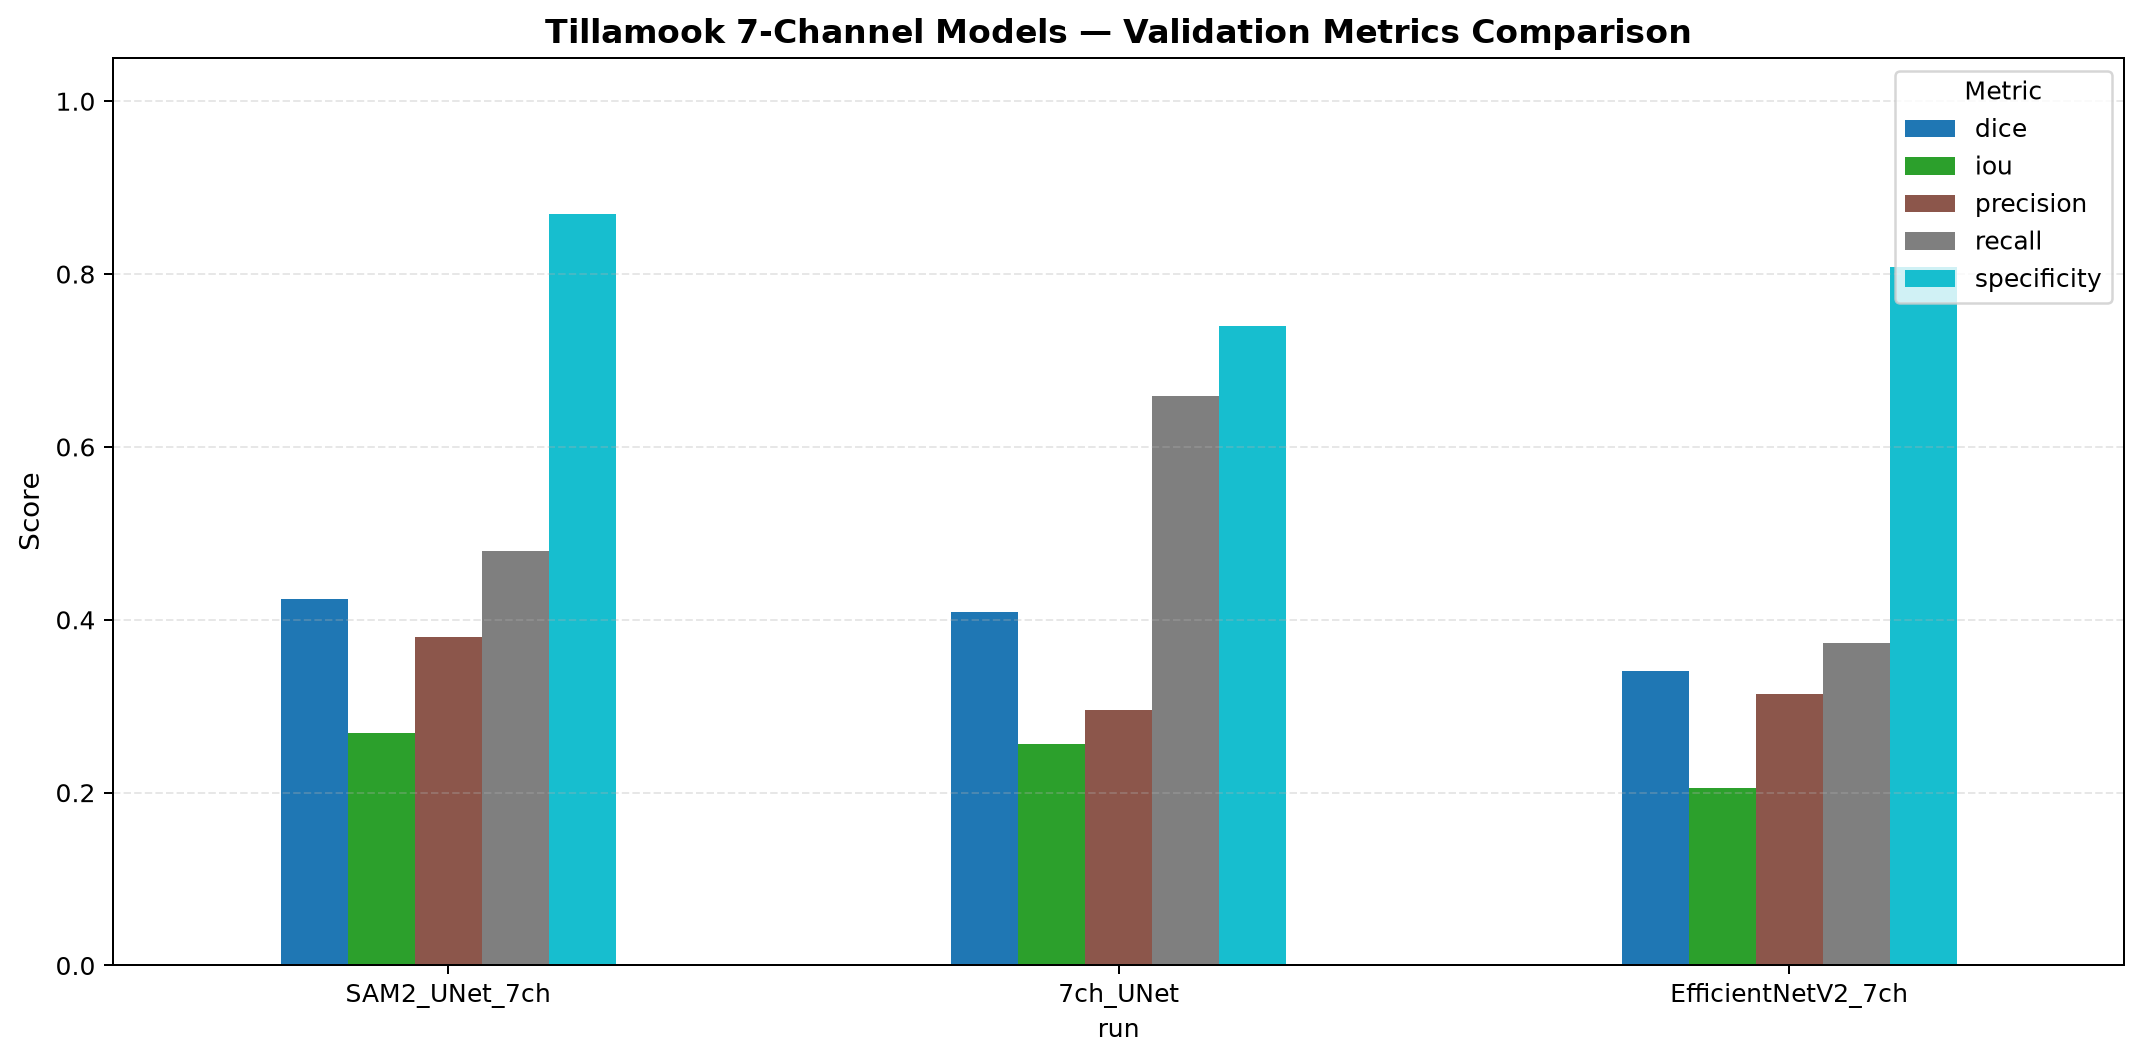

In [4]:
metric_cols = ["dice", "iou", "precision", "recall", "specificity"]

fig, ax = plt.subplots(figsize=(12, 6))
comparison.set_index("run")[metric_cols].plot(
    kind="bar", ax=ax, rot=0, colormap="tab10"
)
ax.set_title("Tillamook 7-Channel Models — Validation Metrics Comparison", fontsize=13, fontweight="bold")
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.legend(title="Metric", fontsize=10, loc="upper right")
plt.tight_layout()

out = FIGDIR / "01_main_metric_comparison.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out)
plt.show()


## 4. Dice and IoU Comparison


Saved: f:\LIDAR\oregon\figures_comparison_7ch_models\02_dice_iou_comparison.png


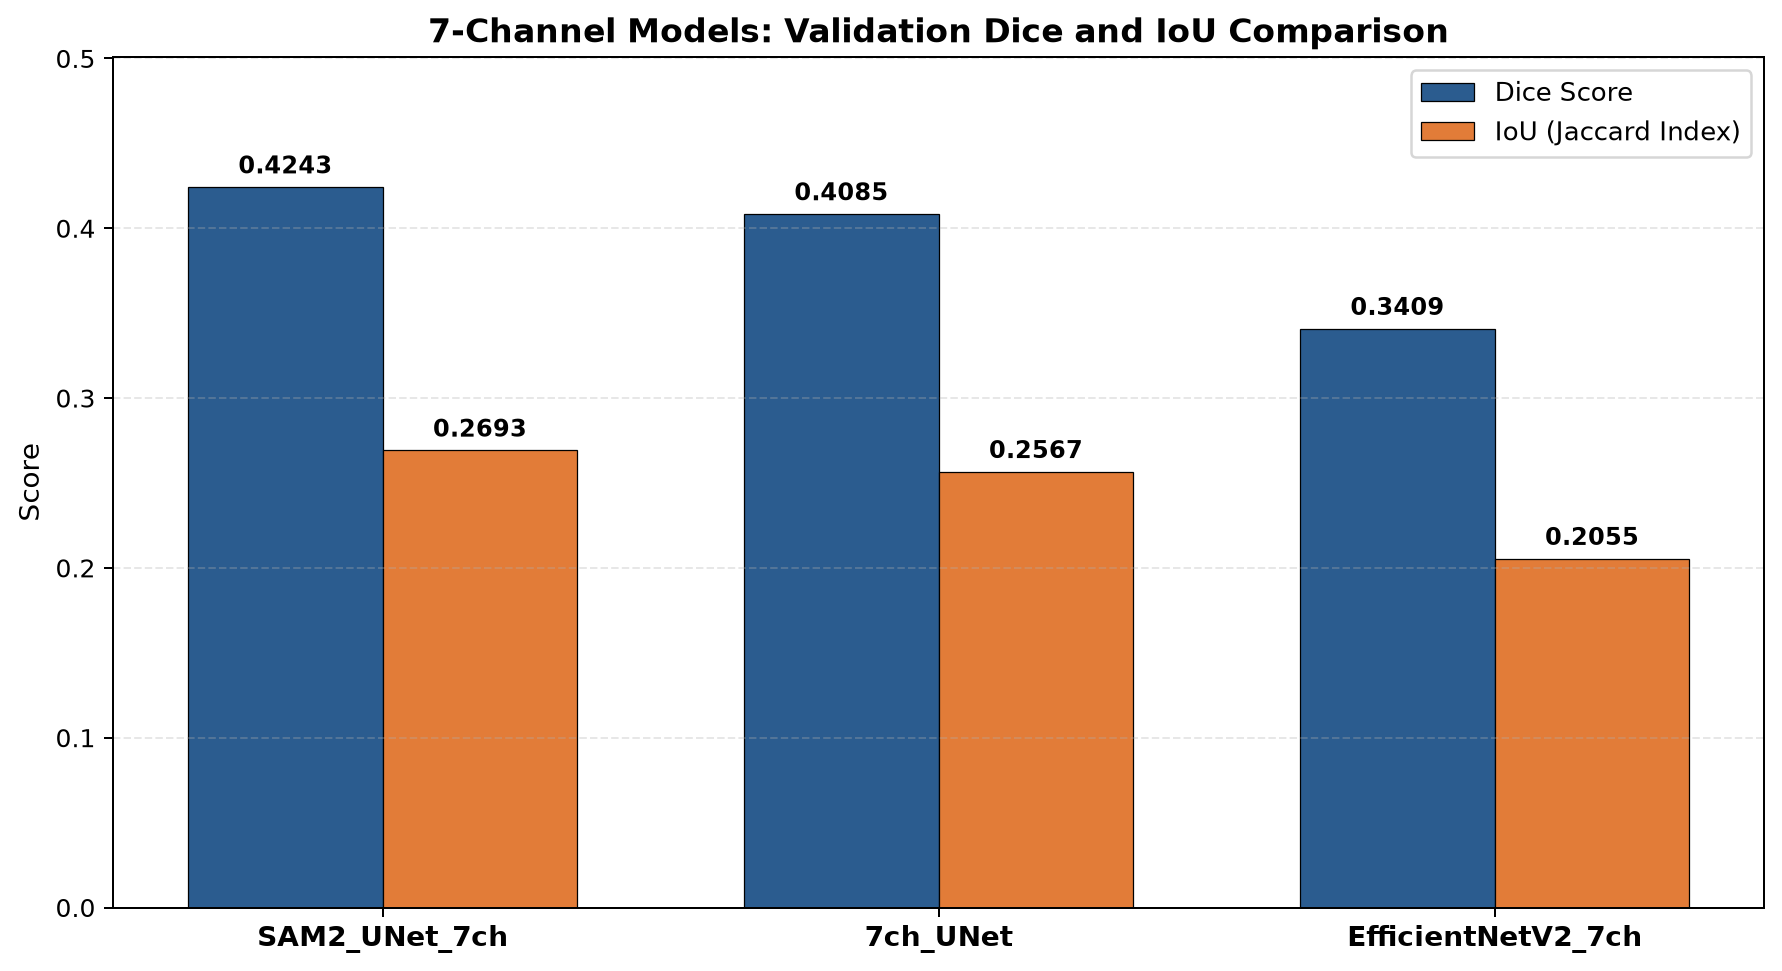

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(comparison))
w = 0.35

rects1 = ax.bar(x - w/2, comparison["dice"], width=w, label="Dice Score", color="#2b5c8f", edgecolor="black", linewidth=0.5)
rects2 = ax.bar(x + w/2, comparison["iou"], width=w, label="IoU (Jaccard Index)", color="#e27c38", edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(comparison["run"], fontsize=11, fontweight="bold")
ax.set_ylabel("Score", fontsize=11)
ax.set_title("7-Channel Models: Validation Dice and IoU Comparison", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(comparison["dice"].max() * 1.18, 0.5))
ax.legend(fontsize=10.5)
ax.grid(axis="y", alpha=0.3, linestyle="--")

for i, v in enumerate(comparison["dice"]):
    ax.text(i - w/2, v + 0.008, f"{v:.4f}", ha="center", fontsize=9.5, fontweight="bold")
for i, v in enumerate(comparison["iou"]):
    ax.text(i + w/2, v + 0.008, f"{v:.4f}", ha="center", fontsize=9.5, fontweight="bold")

plt.tight_layout()
out = FIGDIR / "02_dice_iou_comparison.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out)
plt.show()


## 5. Predicted Positive Area vs Ground Truth (Prevalence Bias)


Saved: f:\LIDAR\oregon\figures_comparison_7ch_models\03_predicted_vs_gt_positive.png
               run  GT_positive_%  Pred_positive_%  Overprediction_Ratio
     SAM2_UNet_7ch         14.260           17.995                 1.262
          7ch_UNet         14.260           31.712                 2.224
EfficientNetV2_7ch         19.039           22.602                 1.187


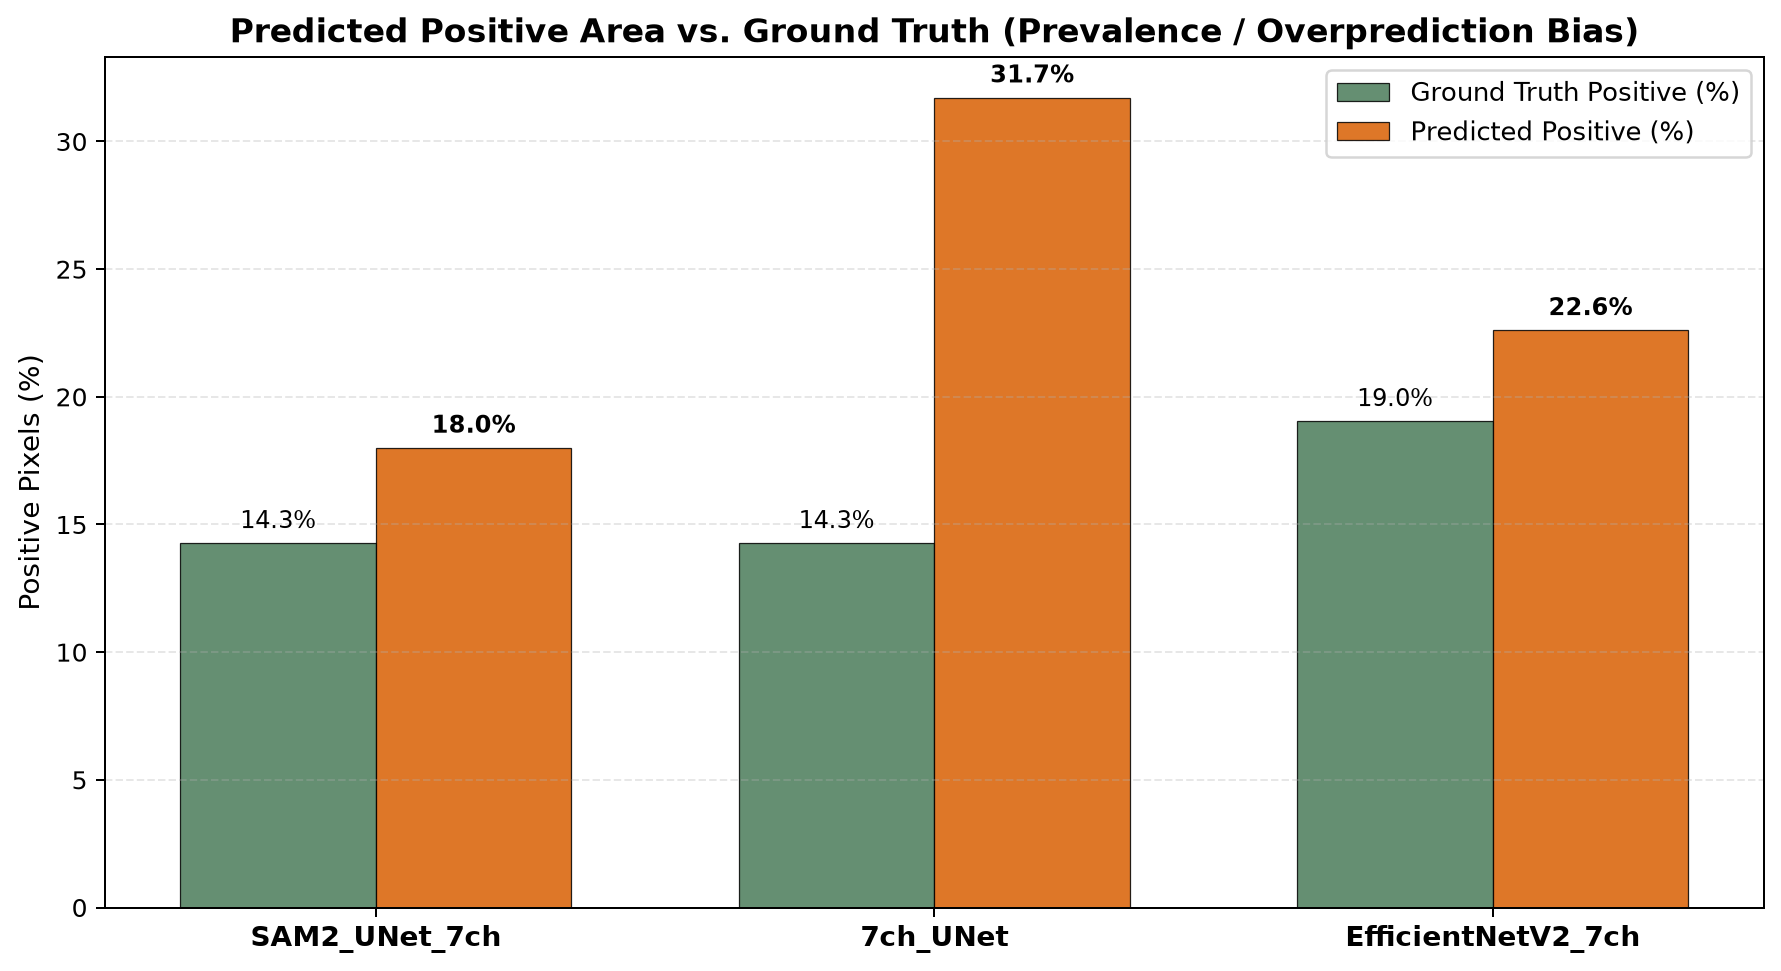

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(comparison))
w = 0.35

ax.bar(x - w/2, 100 * comparison["gt_positive_fraction"], width=w, label="Ground Truth Positive (%)", color="#4a7c59", alpha=0.85, edgecolor="black", linewidth=0.5)
ax.bar(x + w/2, 100 * comparison["predicted_positive_fraction"], width=w, label="Predicted Positive (%)", color="#d95f02", alpha=0.85, edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(comparison["run"], fontsize=11, fontweight="bold")
ax.set_ylabel("Positive Pixels (%)", fontsize=11)
ax.set_title("Predicted Positive Area vs. Ground Truth (Prevalence / Overprediction Bias)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10.5)
ax.grid(axis="y", alpha=0.3, linestyle="--")

for i, v in enumerate(100 * comparison["gt_positive_fraction"]):
    ax.text(i - w/2, v + 0.6, f"{v:.1f}%", ha="center", fontsize=9.5)
for i, v in enumerate(100 * comparison["predicted_positive_fraction"]):
    ax.text(i + w/2, v + 0.6, f"{v:.1f}%", ha="center", fontsize=9.5, fontweight="bold")

plt.tight_layout()
out = FIGDIR / "03_predicted_vs_gt_positive.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out)
plt.show()

bias_df = comparison[["run", "gt_positive_fraction", "predicted_positive_fraction"]].copy()
bias_df["GT_positive_%"] = 100 * bias_df["gt_positive_fraction"]
bias_df["Pred_positive_%"] = 100 * bias_df["predicted_positive_fraction"]
bias_df["Overprediction_Ratio"] = bias_df["predicted_positive_fraction"] / bias_df["gt_positive_fraction"]
print(bias_df[["run", "GT_positive_%", "Pred_positive_%", "Overprediction_Ratio"]].round(3).to_string(index=False))


## 6. FP / FN Pixel Burden Breakdown


Saved: f:\LIDAR\oregon\figures_comparison_7ch_models\04_fp_fn_burden.png


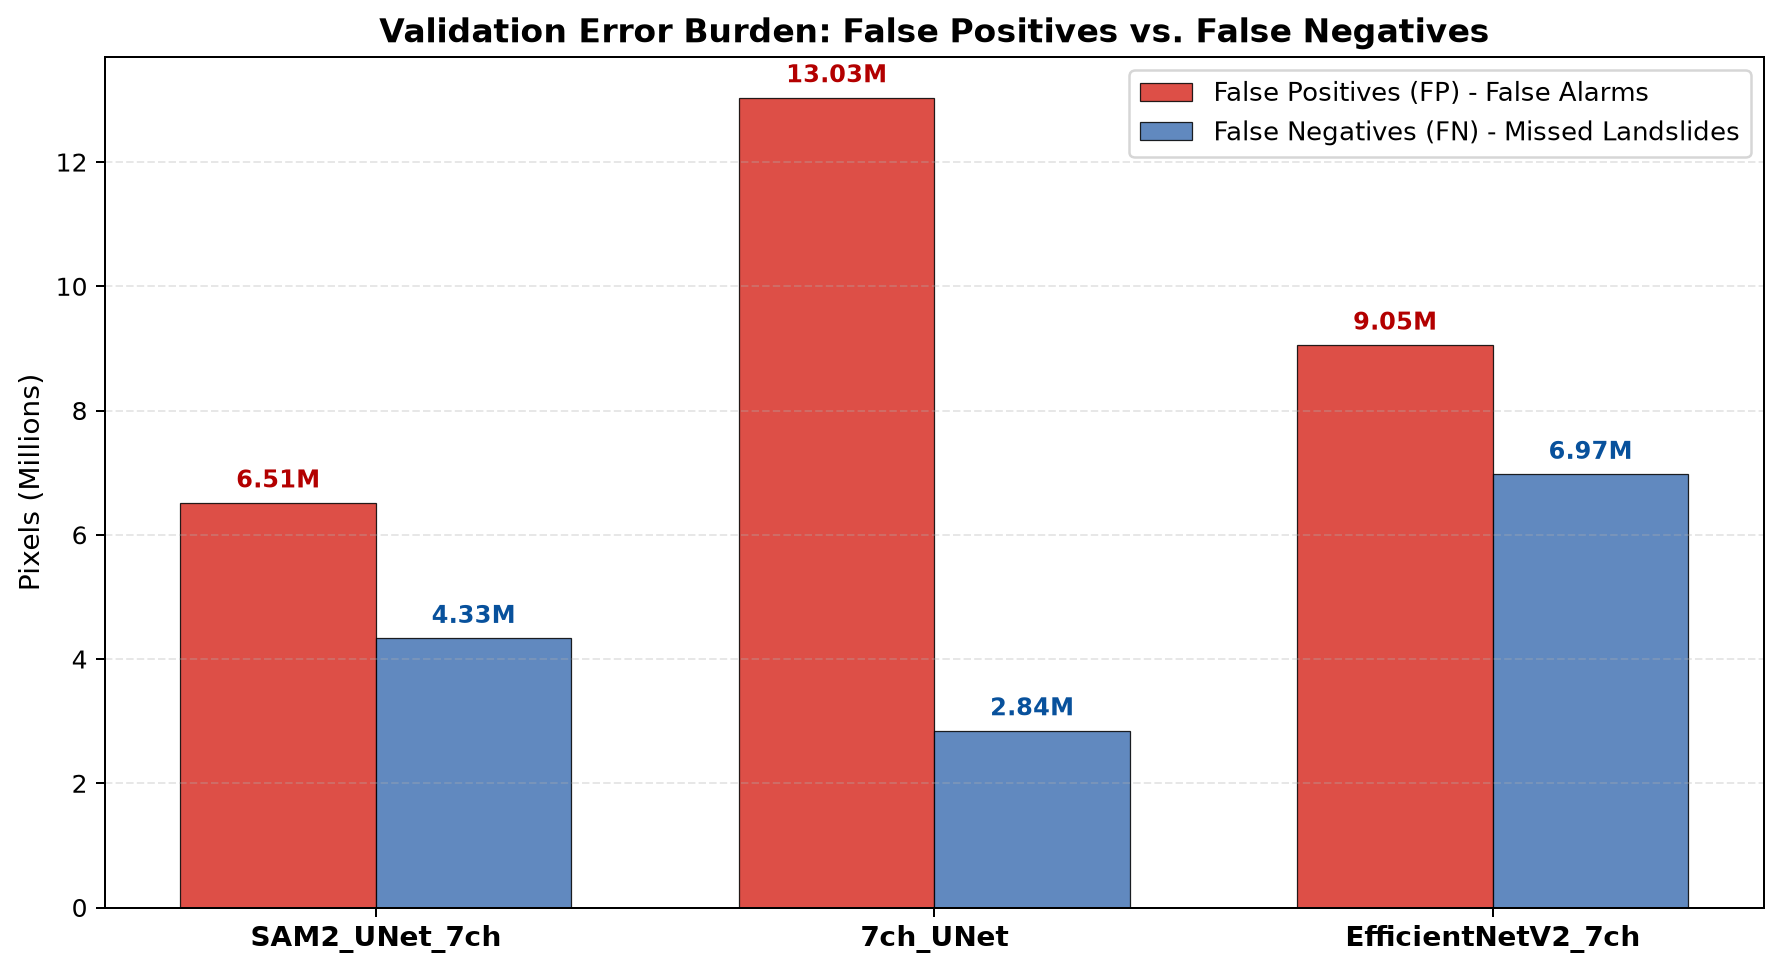

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(comparison))
w = 0.35

ax.bar(x - w/2, comparison["fp"] / 1e6, width=w, label="False Positives (FP) - False Alarms", color="#d73027", alpha=0.85, edgecolor="black", linewidth=0.5)
ax.bar(x + w/2, comparison["fn"] / 1e6, width=w, label="False Negatives (FN) - Missed Landslides", color="#4575b4", alpha=0.85, edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(comparison["run"], fontsize=11, fontweight="bold")
ax.set_ylabel("Pixels (Millions)", fontsize=11)
ax.set_title("Validation Error Burden: False Positives vs. False Negatives", fontsize=13, fontweight="bold")
ax.legend(fontsize=10.5)
ax.grid(axis="y", alpha=0.3, linestyle="--")

for i, v in enumerate(comparison["fp"] / 1e6):
    ax.text(i - w/2, v + 0.25, f"{v:.2f}M", ha="center", fontsize=9.5, fontweight="bold", color="#b30000")
for i, v in enumerate(comparison["fn"] / 1e6):
    ax.text(i + w/2, v + 0.25, f"{v:.2f}M", ha="center", fontsize=9.5, fontweight="bold", color="#08519c")

plt.tight_layout()
out = FIGDIR / "04_fp_fn_burden.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out)
plt.show()


## 7. Training & Validation Dynamics Over Epochs


7ch_UNet            : 50 epochs recorded
EfficientNetV2_7ch  : 40 epochs recorded
SAM2_UNet_7ch       : 40 epochs recorded
Saved: f:\LIDAR\oregon\figures_comparison_7ch_models\05_validation_dice_curves.png
Saved: f:\LIDAR\oregon\figures_comparison_7ch_models\06_training_loss_curves.png


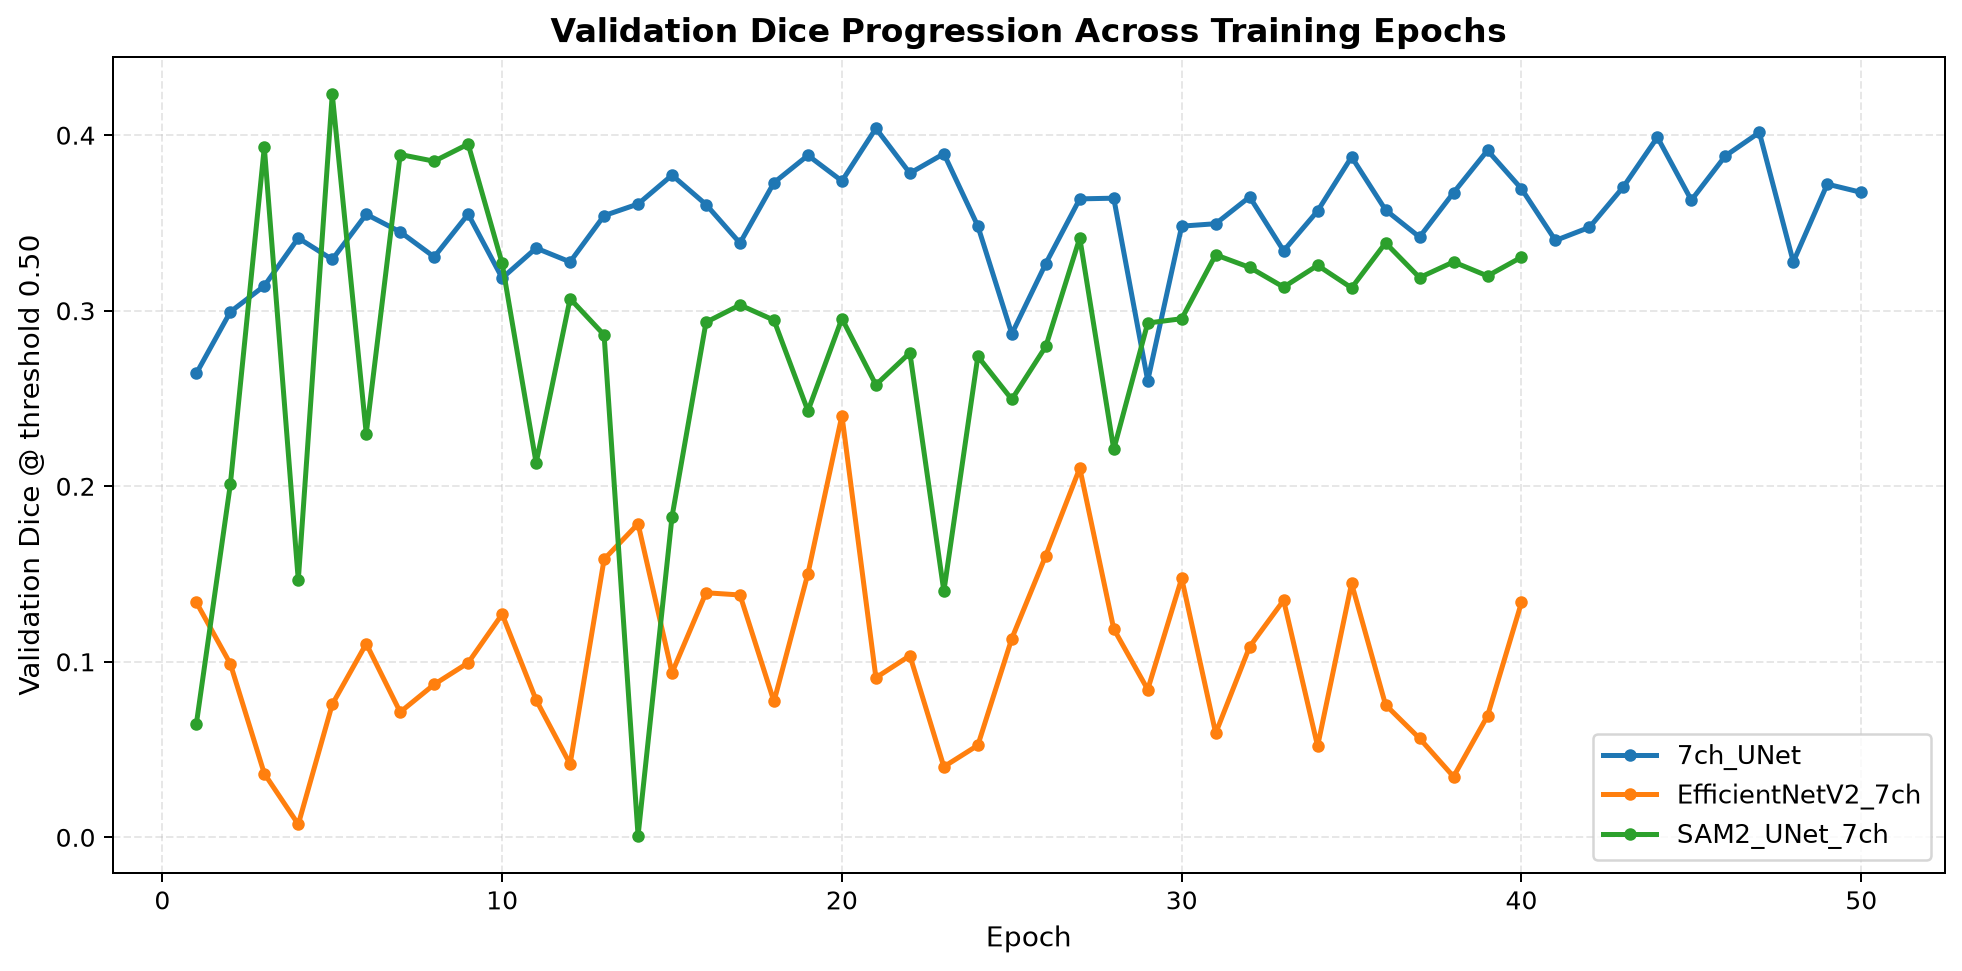

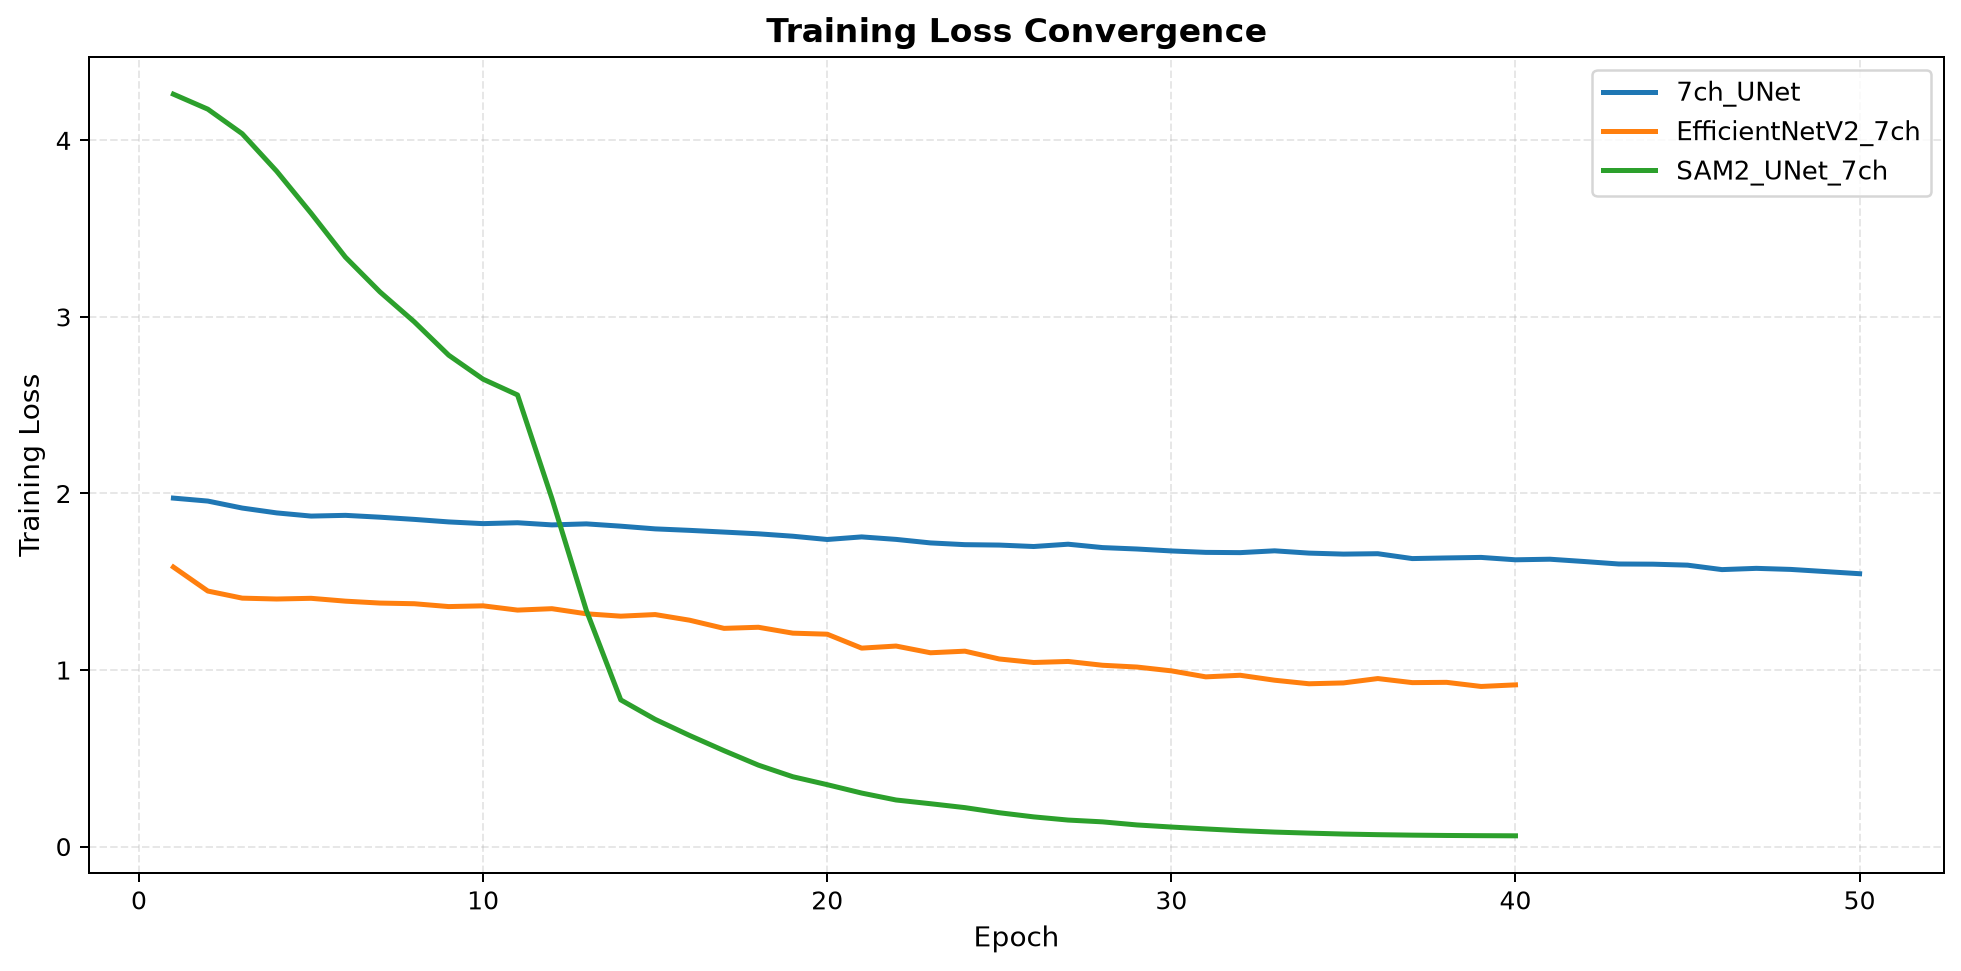

In [8]:
histories = {}
for name, run_dir in RUNS.items():
    p = run_dir / "history.csv"
    if p.exists():
        histories[name] = pd.read_csv(p)
        print(f"{name:20s}: {len(histories[name])} epochs recorded")

colors = {"7ch_UNet": "#1f77b4", "EfficientNetV2_7ch": "#ff7f0e", "SAM2_UNet_7ch": "#2ca02c"}

# 1. Validation Dice vs Epoch
fig1, ax1 = plt.subplots(figsize=(11, 5.5))
for name, h in histories.items():
    possible = [c for c in h.columns if "validation" in c.lower() and "dice" in c.lower()]
    if possible:
        ax1.plot(h["epoch"], h[possible[0]], label=name, color=colors.get(name, None), linewidth=2, marker="o", markersize=4)

ax1.set_title("Validation Dice Progression Across Training Epochs", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Validation Dice @ threshold 0.50", fontsize=11)
ax1.legend(fontsize=10.5)
ax1.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
out1 = FIGDIR / "05_validation_dice_curves.png"
plt.savefig(out1, dpi=200, bbox_inches="tight")
print("Saved:", out1)
plt.show()

# 2. Training Loss vs Epoch
fig2, ax2 = plt.subplots(figsize=(11, 5.5))
for name, h in histories.items():
    if "train_loss" in h.columns:
        ax2.plot(h["epoch"], h["train_loss"], label=name, color=colors.get(name, None), linewidth=2)

ax2.set_title("Training Loss Convergence", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Training Loss", fontsize=11)
ax2.legend(fontsize=10.5)
ax2.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
out2 = FIGDIR / "06_training_loss_curves.png"
plt.savefig(out2, dpi=200, bbox_inches="tight")
print("Saved:", out2)
plt.show()


## 8. Validation Threshold Sweeps (Sensitivity & Calibration)


Saved: f:\LIDAR\oregon\figures_comparison_7ch_models\07_threshold_sweep_dice.png


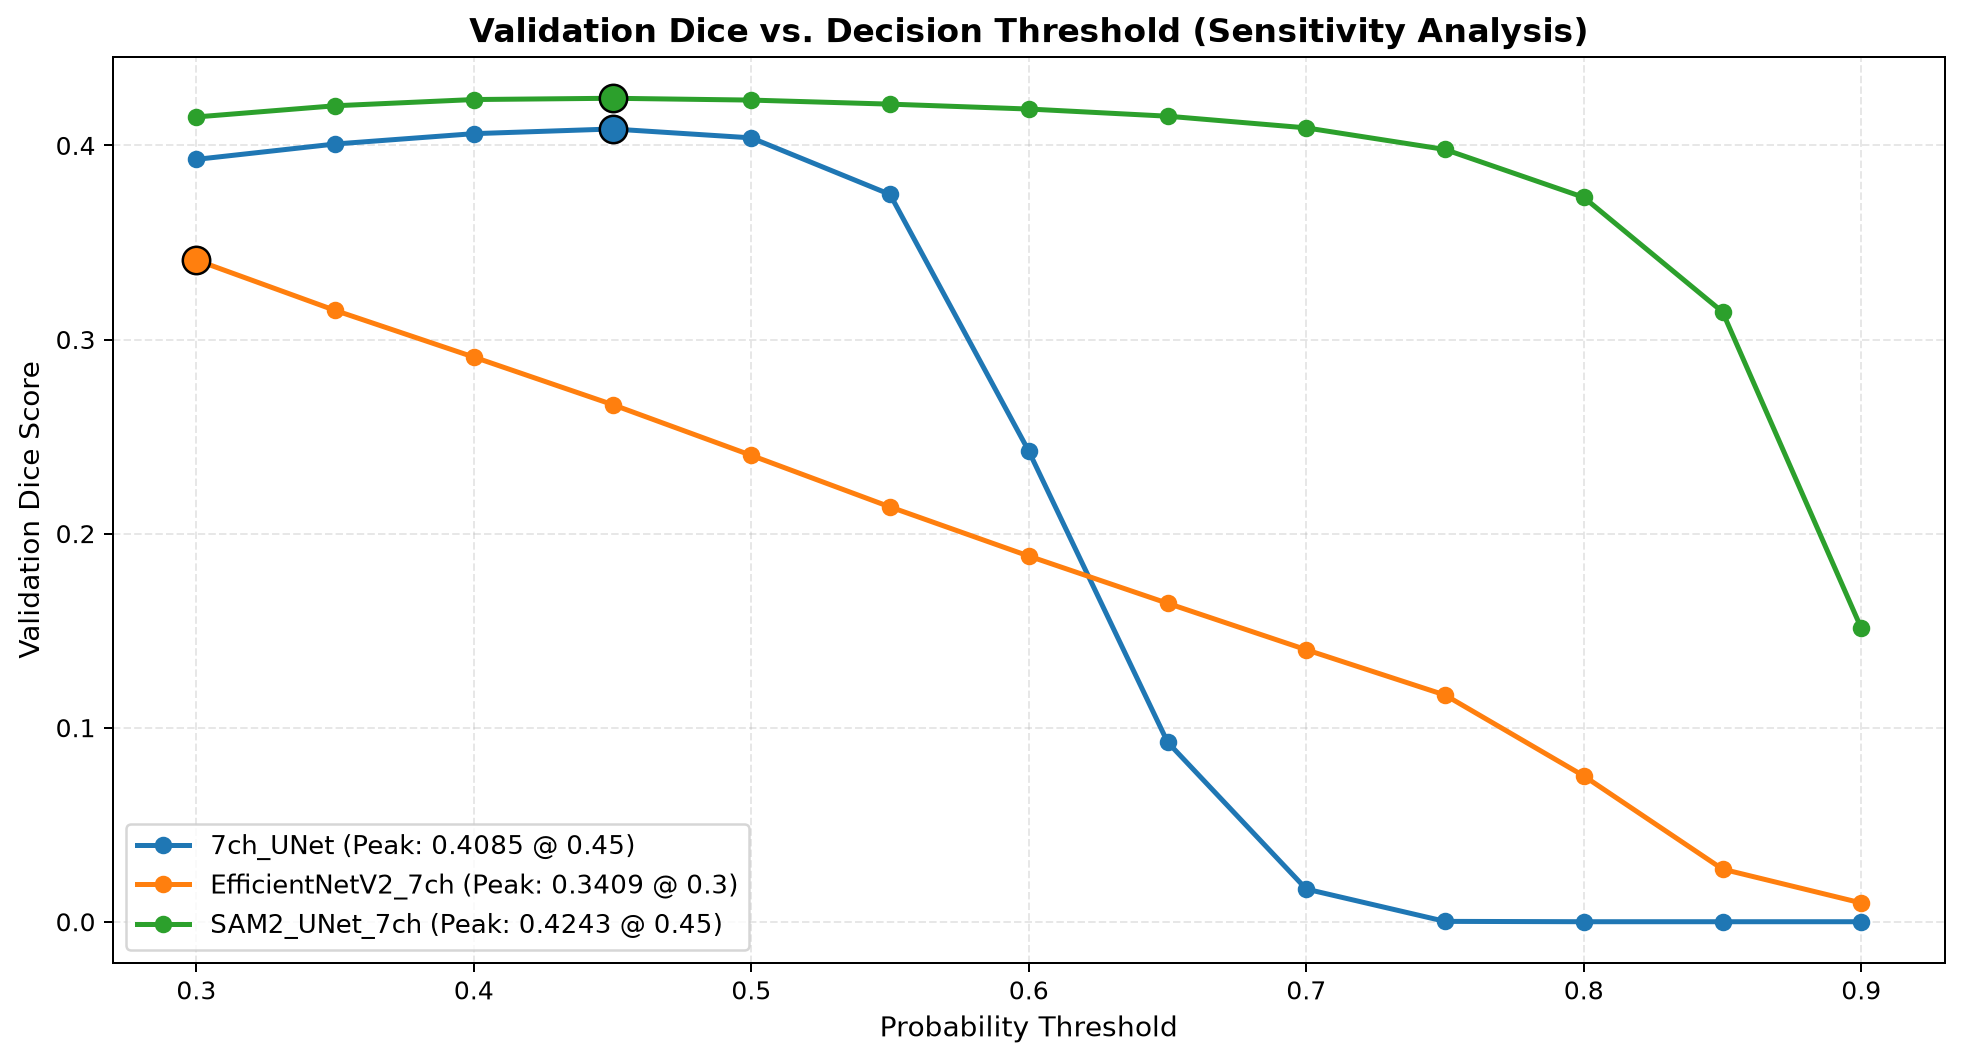

In [9]:
sweeps = {}
for name, run_dir in RUNS.items():
    p = run_dir / "validation_threshold_sweep.csv"
    if p.exists():
        sweeps[name] = pd.read_csv(p)

fig, ax = plt.subplots(figsize=(11, 6))
colors = {"7ch_UNet": "#1f77b4", "EfficientNetV2_7ch": "#ff7f0e", "SAM2_UNet_7ch": "#2ca02c"}

for name, s in sweeps.items():
    best_idx = s["dice"].idxmax()
    best_t = s.loc[best_idx, "threshold"]
    best_d = s.loc[best_idx, "dice"]
    c = colors.get(name, None)
    ax.plot(s["threshold"], s["dice"], marker="o", label=f"{name} (Peak: {best_d:.4f} @ {best_t})", color=c, linewidth=2)
    ax.scatter([best_t], [best_d], color=c, s=120, edgecolors="black", zorder=5)

ax.set_title("Validation Dice vs. Decision Threshold (Sensitivity Analysis)", fontsize=13, fontweight="bold")
ax.set_xlabel("Probability Threshold", fontsize=11)
ax.set_ylabel("Validation Dice Score", fontsize=11)
ax.legend(fontsize=10.5)
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout()

out = FIGDIR / "07_threshold_sweep_dice.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out)
plt.show()


### Deep Dive: SAM2-UNet 7ch Threshold Trade-offs


Saved: f:\LIDAR\oregon\figures_comparison_7ch_models\08_sam2unet_threshold_tradeoff.png
 threshold   dice    iou  precision  recall  specificity  gt_positive_fraction  predicted_positive_fraction
      0.30 0.4147 0.2616     0.3351  0.5439       0.8205                0.1426                       0.2315
      0.35 0.4204 0.2662     0.3531  0.5195       0.8417                0.1426                       0.2098
      0.40 0.4237 0.2688     0.3683  0.4987       0.8577                0.1426                       0.1931
      0.45 0.4243 0.2693     0.3803  0.4799       0.8699                0.1426                       0.1800
      0.50 0.4234 0.2685     0.3903  0.4625       0.8798                0.1426                       0.1690
      0.55 0.4213 0.2669     0.3995  0.4455       0.8886                0.1426                       0.1590
      0.60 0.4188 0.2648     0.4098  0.4281       0.8975                0.1426                       0.1490
      0.65 0.4151 0.2619     0.4218  0.4085     

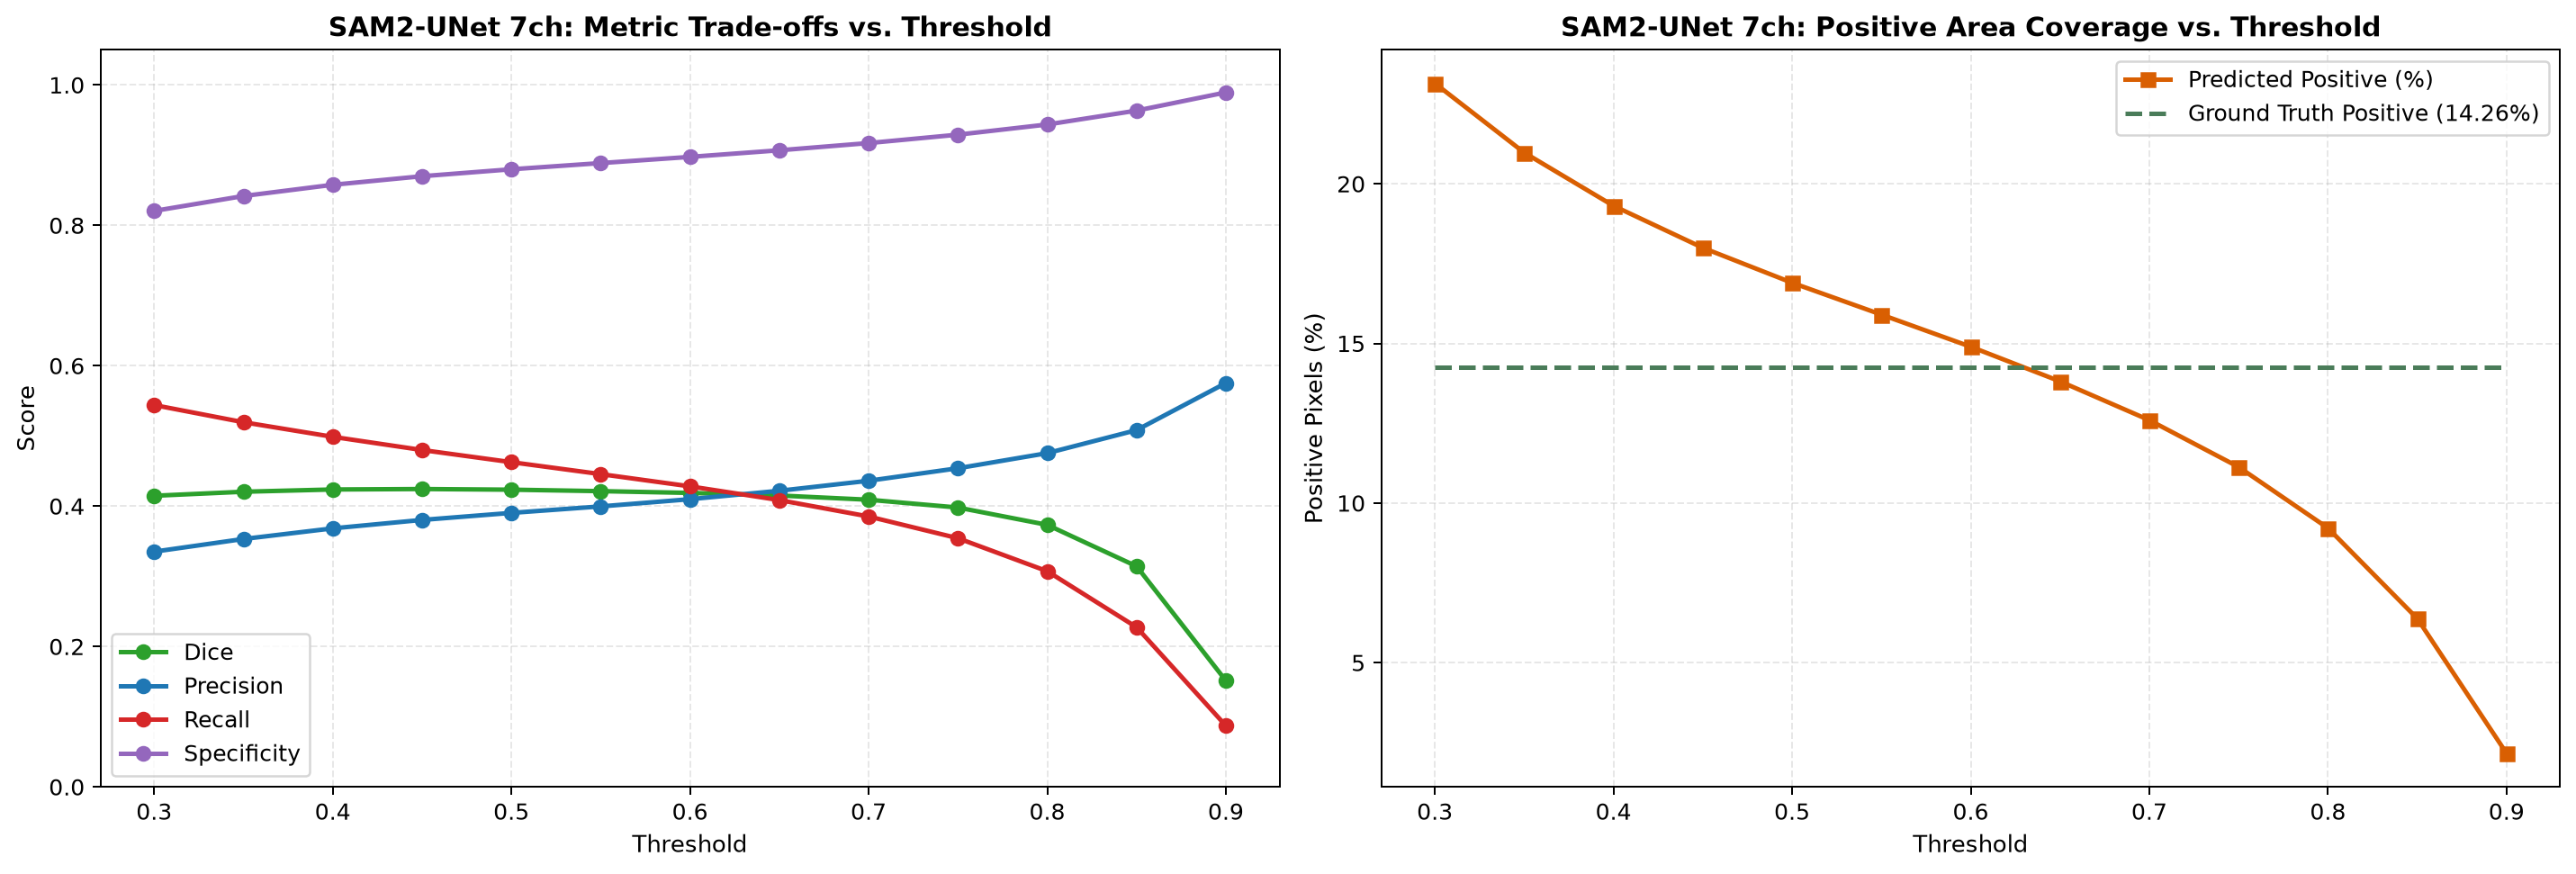

In [10]:
sweeps = {name: pd.read_csv(rdir / "validation_threshold_sweep.csv") for name, rdir in RUNS.items() if (rdir / "validation_threshold_sweep.csv").exists()}
sam2_sweep = sweeps["SAM2_UNet_7ch"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# Subplot 1: Metric trade-offs
for metric, color in [("dice", "#2ca02c"), ("precision", "#1f77b4"), ("recall", "#d62728"), ("specificity", "#9467bd")]:
    ax1.plot(sam2_sweep["threshold"], sam2_sweep[metric], marker="o", label=metric.capitalize(), color=color, linewidth=2)

ax1.set_title("SAM2-UNet 7ch: Metric Trade-offs vs. Threshold", fontsize=12, fontweight="bold")
ax1.set_xlabel("Threshold", fontsize=10.5)
ax1.set_ylabel("Score", fontsize=10.5)
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, linestyle="--")

# Subplot 2: Predicted positive fraction vs GT
ax2.plot(sam2_sweep["threshold"], 100 * sam2_sweep["predicted_positive_fraction"], marker="s", color="#d95f02", linewidth=2, label="Predicted Positive (%)")
ax2.plot(sam2_sweep["threshold"], 100 * sam2_sweep["gt_positive_fraction"], linestyle="--", color="#4a7c59", linewidth=2, label="Ground Truth Positive (14.26%)")
ax2.set_title("SAM2-UNet 7ch: Positive Area Coverage vs. Threshold", fontsize=12, fontweight="bold")
ax2.set_xlabel("Threshold", fontsize=10.5)
ax2.set_ylabel("Positive Pixels (%)", fontsize=10.5)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
out = FIGDIR / "08_sam2unet_threshold_tradeoff.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out)
plt.show()

print(sam2_sweep[["threshold", "dice", "iou", "precision", "recall", "specificity", "gt_positive_fraction", "predicted_positive_fraction"]].round(4).to_string(index=False))


## 9. Model Size vs Performance (Efficiency & Pareto Analysis)


Saved: f:\LIDAR\oregon\figures_comparison_7ch_models\09_model_size_vs_dice.png
               run  total_params_M  trainable_params_M   dice    iou  precision  recall
     SAM2_UNet_7ch        216.5299              4.3806 0.4243 0.2693     0.3803  0.4799
          7ch_UNet          7.7671              7.7671 0.4085 0.2567     0.2961  0.6584
EfficientNetV2_7ch         22.0943             22.0943 0.3409 0.2055     0.3141  0.3729


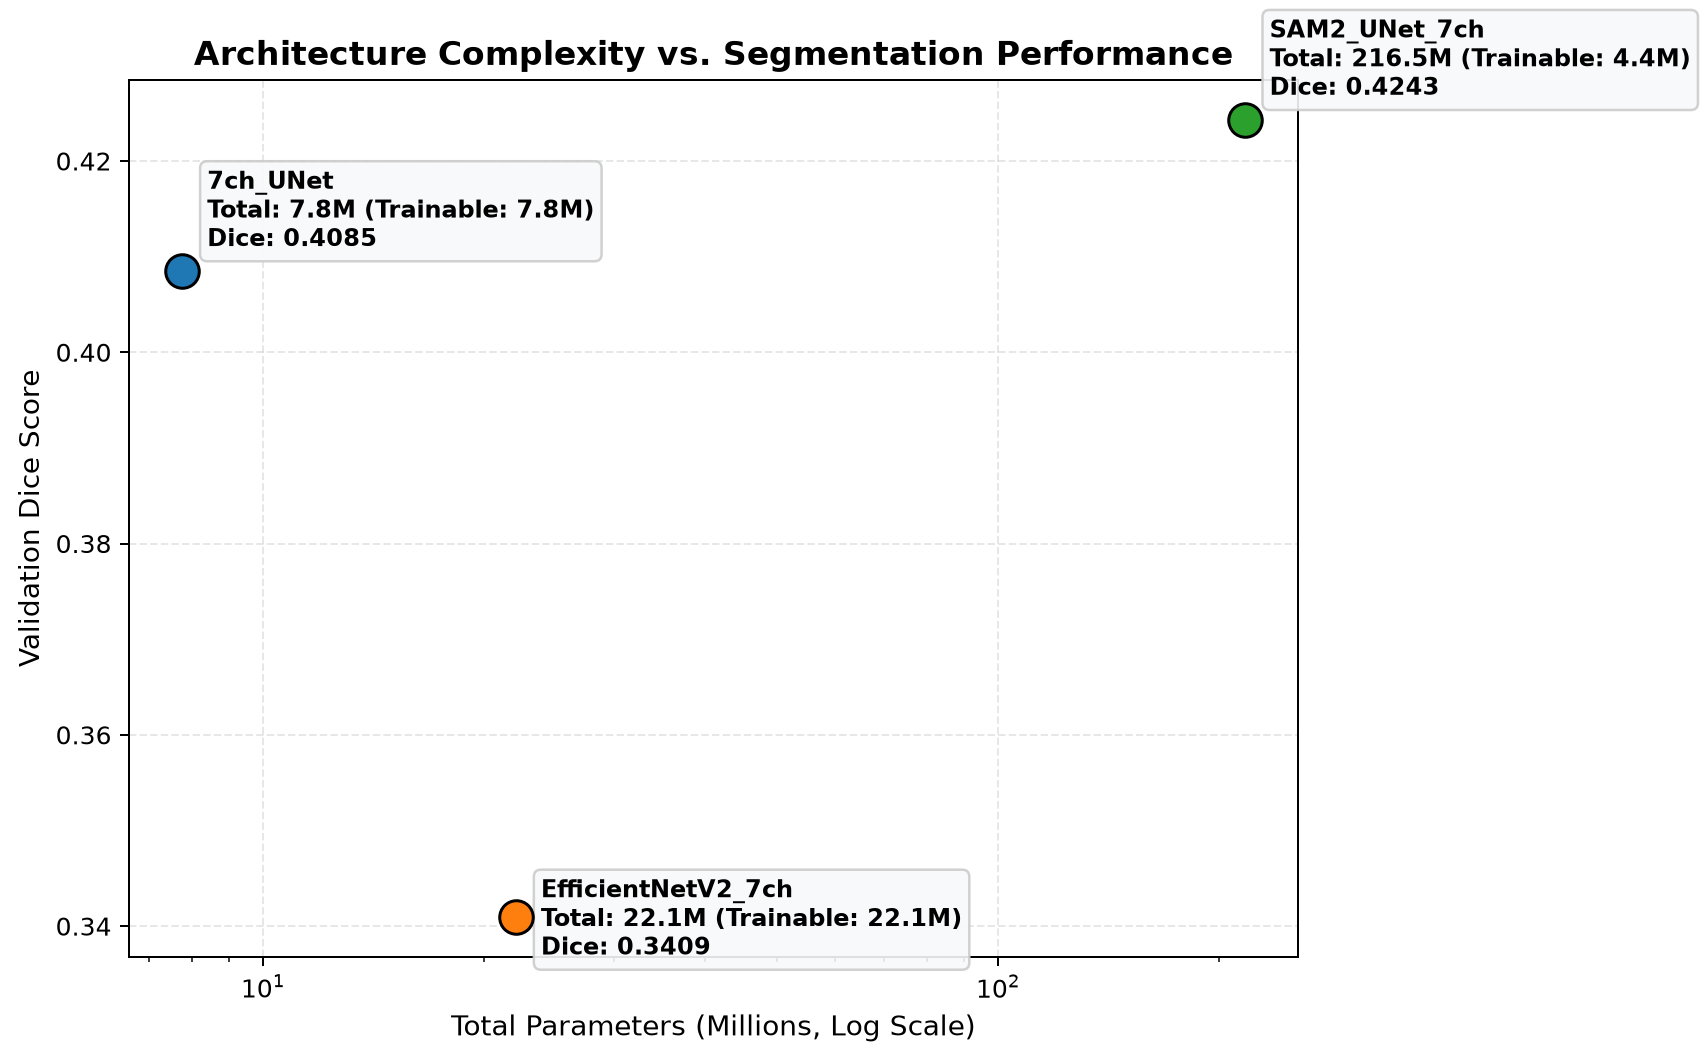

In [11]:
eff = comparison[["run", "architecture", "total_params", "trainable_params", "dice", "iou", "precision", "recall"]].copy()
eff["total_params_M"] = eff["total_params"] / 1e6
eff["trainable_params_M"] = eff["trainable_params"] / 1e6

fig, ax = plt.subplots(figsize=(9.5, 6))
colors = {"7ch_UNet": "#1f77b4", "EfficientNetV2_7ch": "#ff7f0e", "SAM2_UNet_7ch": "#2ca02c"}

for _, r in eff.iterrows():
    c = colors.get(r["run"], "blue")
    ax.scatter(r["total_params_M"], r["dice"], s=180, color=c, edgecolors="black", linewidth=1.2, zorder=5)
    ann_text = f"{r['run']}\nTotal: {r['total_params_M']:.1f}M (Trainable: {r['trainable_params_M']:.1f}M)\nDice: {r['dice']:.4f}"
    ax.annotate(
        ann_text,
        (r["total_params_M"], r["dice"]),
        xytext=(10, -15 if r["run"] == "EfficientNetV2_7ch" else 10),
        textcoords="offset points",
        fontsize=9.5,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="#f8f9fa", ec="#cccccc", alpha=0.9)
    )

ax.set_xscale("log")
ax.set_xlabel("Total Parameters (Millions, Log Scale)", fontsize=11)
ax.set_ylabel("Validation Dice Score", fontsize=11)
ax.set_title("Architecture Complexity vs. Segmentation Performance", fontsize=13, fontweight="bold")
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout()

out = FIGDIR / "09_model_size_vs_dice.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out)
plt.show()

print(eff[["run", "total_params_M", "trainable_params_M", "dice", "iou", "precision", "recall"]].round(4).to_string(index=False))


## 10. Multi-Attribute Performance Profile


Saved: f:\LIDAR\oregon\figures_comparison_7ch_models\10_multi_attribute_radar_comparison.png


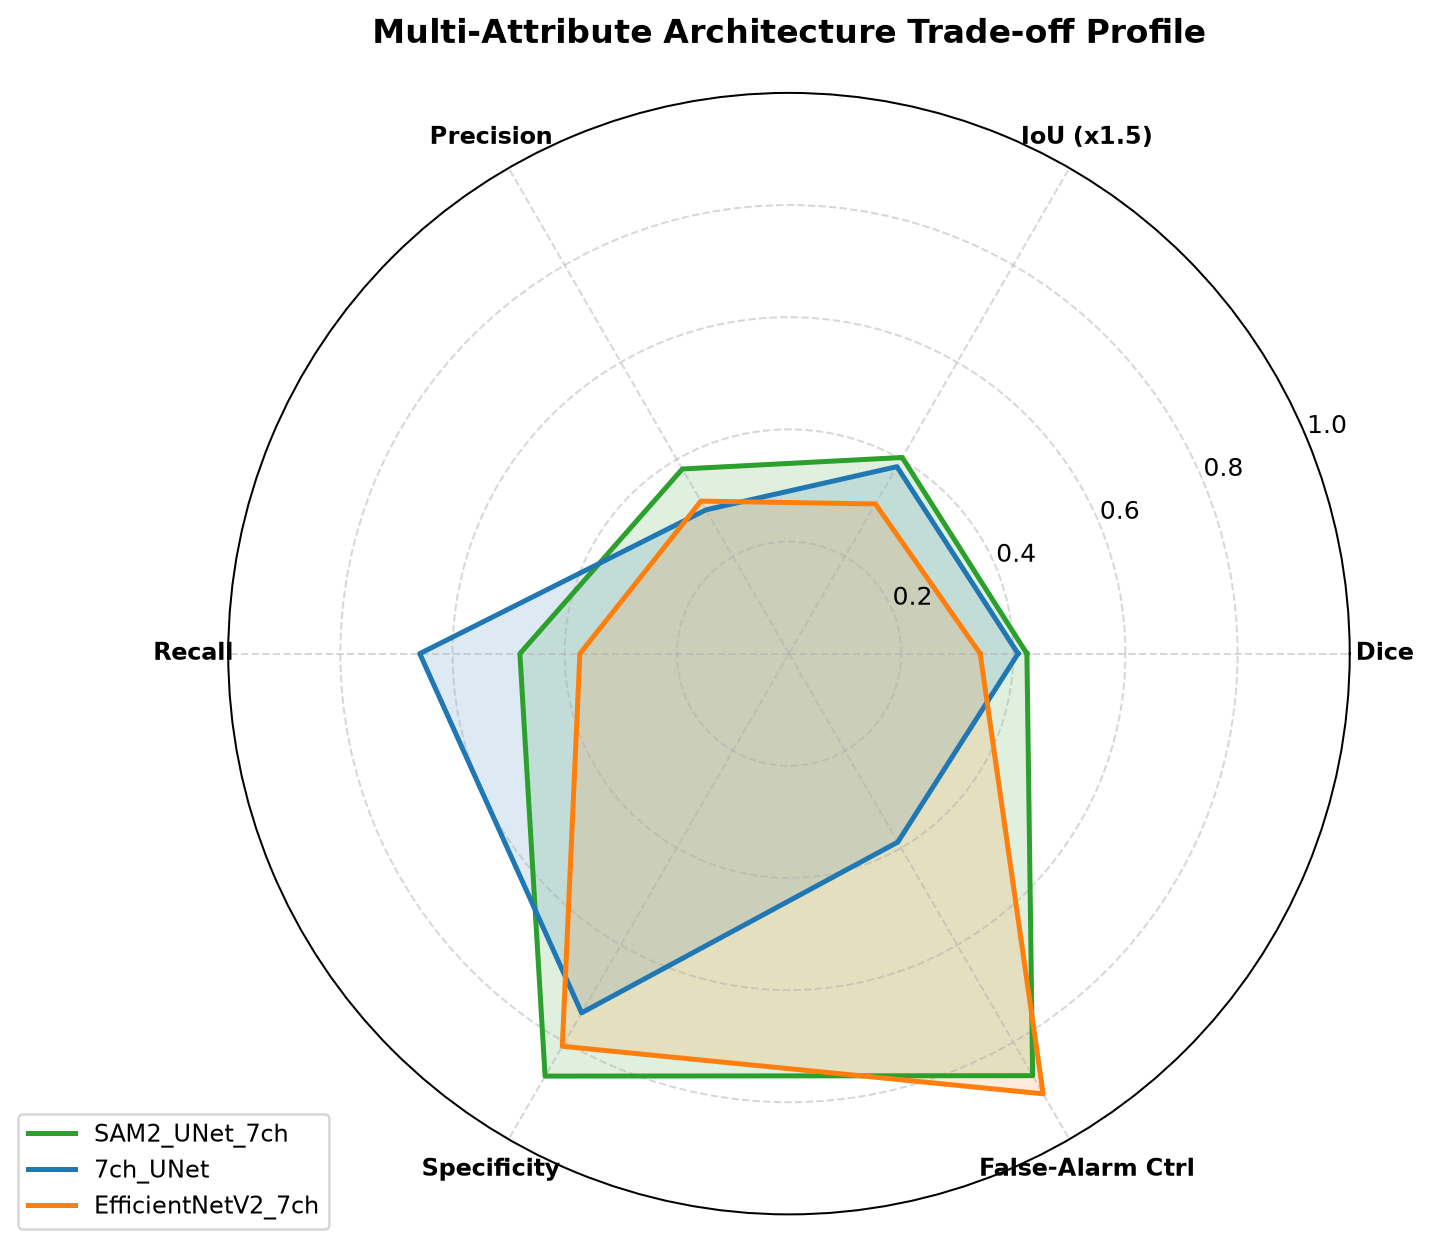

In [12]:
categories = ["Dice", "IoU (x1.5)", "Precision", "Recall", "Specificity", "False-Alarm Ctrl"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = {"7ch_UNet": "#1f77b4", "EfficientNetV2_7ch": "#ff7f0e", "SAM2_UNet_7ch": "#2ca02c"}

for _, r in comparison.iterrows():
    overpred = r["predicted_positive_fraction"] / r["gt_positive_fraction"]
    fa_control = max(0.0, 1.0 - (overpred - 1.0) / 2.0)
    values = [
        r["dice"],
        min(1.0, r["iou"] * 1.5),
        r["precision"],
        r["recall"],
        r["specificity"],
        fa_control
    ]
    values += values[:1]
    c = colors.get(r["run"], None)
    ax.plot(angles, values, linewidth=2, linestyle="solid", label=r["run"], color=c)
    ax.fill(angles, values, color=c, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9.5, fontweight="bold")
ax.set_ylim(0, 1.0)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="upper right", bbox_to_anchor=(0.1, 0.1), fontsize=9.5)
ax.set_title("Multi-Attribute Architecture Trade-off Profile", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()

out = FIGDIR / "10_multi_attribute_radar_comparison.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out)
plt.show()


## 11. Development Winner Summary & Key Takeaways


Winning Model                                            SAM2_UNet_7ch
Architecture                 SAM2-UNet Hiera-L + terrain input adapter
Best Epoch                                                           5
Optimal Threshold                                                 0.45
Validation Dice                                               0.424308
Validation IoU                                                0.269284
Precision                                                     0.380277
Recall                                                        0.479871
Specificity                                                    0.86993
Predicted Positive %                                         17.995317
Ground Truth %                                               14.260496
Dice Gain vs. 7ch UNet                                         +0.0158
FP Reduction vs. 7ch UNet                              50.0% reduction
Saved: f:\LIDAR\oregon\figures_comparison_7ch_models\11_winner_summary_card.p

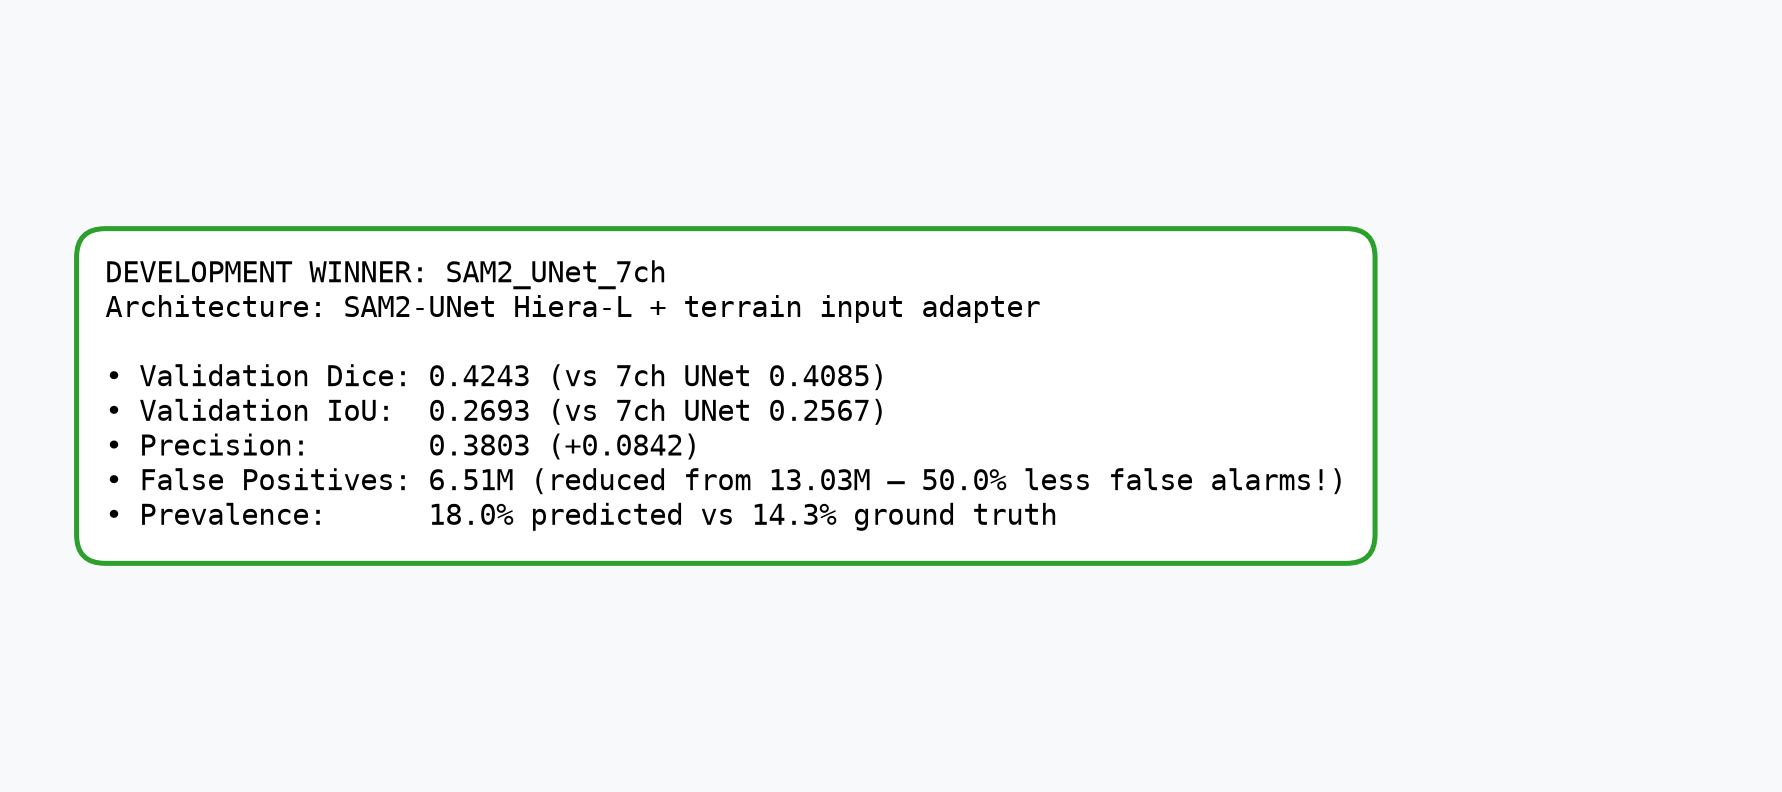

In [13]:
winner = comparison.iloc[0]
baseline = comparison[comparison["run"] == "7ch_UNet"].iloc[0]

summary = pd.Series({
    "Winning Model": winner["run"],
    "Architecture": winner["architecture"],
    "Best Epoch": int(winner["best_epoch"]),
    "Optimal Threshold": winner["threshold"],
    "Validation Dice": winner["dice"],
    "Validation IoU": winner["iou"],
    "Precision": winner["precision"],
    "Recall": winner["recall"],
    "Specificity": winner["specificity"],
    "Predicted Positive %": 100 * winner["predicted_positive_fraction"],
    "Ground Truth %": 100 * winner["gt_positive_fraction"],
    "Dice Gain vs. 7ch UNet": f"{(winner['dice'] - baseline['dice']):+.4f}",
    "FP Reduction vs. 7ch UNet": f"{(1.0 - winner['fp'] / baseline['fp']) * 100:.1f}% reduction"
})
print(summary.to_string())

fig, ax = plt.subplots(figsize=(10, 4.5), facecolor="#f8f9fa")
ax.axis("off")

banner_text = (
    f"DEVELOPMENT WINNER: {winner['run']}\n"
    f"Architecture: {winner['architecture']}\n\n"
    f"• Validation Dice: {winner['dice']:.4f} (vs 7ch UNet {baseline['dice']:.4f})\n"
    f"• Validation IoU:  {winner['iou']:.4f} (vs 7ch UNet {baseline['iou']:.4f})\n"
    f"• Precision:       {winner['precision']:.4f} (+{winner['precision'] - baseline['precision']:.4f})\n"
    f"• False Positives: {winner['fp']/1e6:.2f}M (reduced from {baseline['fp']/1e6:.2f}M — {(1.0 - winner['fp']/baseline['fp'])*100:.1f}% less false alarms!)\n"
    f"• Prevalence:      {100*winner['predicted_positive_fraction']:.1f}% predicted vs {100*winner['gt_positive_fraction']:.1f}% ground truth"
)

ax.text(
    0.05, 0.5, banner_text,
    fontsize=11.5, fontfamily="monospace",
    verticalalignment="center",
    bbox=dict(boxstyle="round,pad=1", facecolor="white", edgecolor="#2ca02c", linewidth=2)
)
plt.tight_layout()

out = FIGDIR / "11_winner_summary_card.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
print("Saved:", out)
plt.show()


## Protocol Reminder

- These are **validation-only** plots.
- Do **not** add the locked `test` split while tuning architectures or selecting decision thresholds.
- Current development winner: **`SAM2_UNet_7ch`** with **Dice = 0.4243**, cutting false alarms by **50.0%** relative to the 7-channel Mini U-Net baseline.
